### Multiple linear regression


The primary use of **Multiple Linear Regression (MLR)** is to measure the impact of several factors on a specific result.  
It acts as an extension of **Simple Linear Regression**, following the same core principles, except the dependent variable $y$ is now linked **to more than one independent variable** $x_n$ $$y = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n + \epsilon$$ Feature Correlation: In some cases, features may be correlated with each other; in such instances, only one of them should be utilized to maintain model stability.Data is represented as a matrix (set of vectors) to leverage Linear Algebra properties. This approach is far more efficient than traditional methods (like for loops) and is referred to as Vectorization.$$y = X \cdot W + b$$

In [1]:

#importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Generating random data for multiple linear regression
np.random.seed(1)
X = np.random.random(1000).reshape((200,5))*10
W=np.array([3,5,4,2,8])
noise = np.random.random(200)
bias = 2
y = np.dot(X,W)+bias

* We use the matrix representation here to convert the linear equation $y = w_0 + w_1x_1 + w_2x_2 \dots$ into a simple dot product $y = X \cdot W + b$.  

* Dot Product is not a standard multiplication. It is specifically applied to vectors (since matrices are sets of vectors).   

* It does not simply multiply each element by its counterpart ($A_i \times B_i$).Instead, it calculates the weighted sum by multiplying each element in a row by its corresponding element in the column and summing them up.  

* Although this is a simplified view, it is exactly what allows the operation to represent a Linear Equation.
* Non-Commutativity: This specific row-by-column property is why the operation is Non-Commutative ($X \cdot W \neq W \cdot X$).  

* Order Sensitivity: Taking the row values of the first matrix and multiplying them by the column of the second yields a completely different result (or becomes mathematically impossible due to dimension mismatch) if the order is reversed

In [3]:
cost = lambda y_true , y_pred :np.mean(y_true-y_pred)/2

$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$ $$f_{w,b}(x^{(i)}) = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$

This **loss function** expresses how **poorly** the prediction was, or rather, how far the prediction deviated from the actual result. The error value is calculated for each sample, and the average is. taken to obtain a close approximation of **the model's performance** with specific weights  
  

It can be observed that this loss function is almost identical to the **mean squared error** function used in **simple linear regression** forecasting, except that the averaging part was doubled to account for the original size. This was done for mathematical reasons to simplify the derivative during **Gradient** calculation.

In [ ]:
def gradientDescent(X, y, learning_rate, epochs):
    """
    Performs gradient descent to optimize the weights of a linear regression model.
    Parameters:
    X (numpy.ndarray): The input features.
    y (numpy.ndarray): The target values.
    learning_rate (float): The learning rate for gradient descent.
    epochs (int): The number of iterations for gradient descent.
    Returns:
    numpy.ndarray: The optimized weights.
    numpy.ndarray: The cost values for each epoch."""
    m = len(y)
    X = np.c_[X, np.ones(m)] 
    w_num = X.shape[1]
    W = np.zeros(w_num)
    costs = []
    for i in range(epochs):
        pred = np.dot(X, W)
        error = pred - y
        gradient = (1/m) * np.dot(X.T, error)
        W = W - learning_rate * gradient
        current_cost = cost(y_pred=pred, y_true=y)
        costs.append(current_cost)
    return W, np.array(costs)
w_result ,costs=gradientDescent(X,y,10e-4,200)


update weights equation:  
$$W = W-\frac{\alpha}{m} \sum_{i=1}^{m}( f_{w,b}(x^{i})-y^{i})x^{i}$$
  
  It can be observed that the properties of the computational method (dot multiplication) were used to perform the operations, thus eliminating the need for nested loops. This is a practical application of **Vectorization**  
  
It can also be noted that we have considered bias as one of the weights, and this requires modifying the properties matrix by adding a column of 1 number to actually represent bias.


/home/lamine/AI-Foundations-Lab/linearRegression/../utils.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


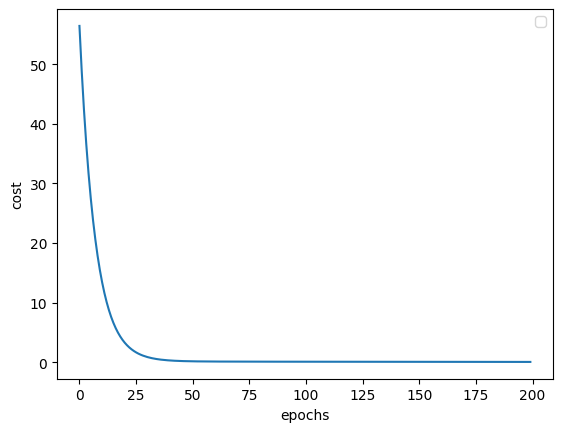

In [5]:
# plotting the learning curve
import sys
sys.path.append("..")
from utils import plot_learning_curve
plot_learning_curve(costs)
